# Usage and Addiction Analysis

## Import Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the data

In [3]:
df = pd.read_csv('/Users/stevenherrerabonilla/Documents/Date_Analyst_Portafolio/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

## Inspection of data

In [4]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

## Statistical Summary
Before correcting data types, we generate a descriptive summary to get a first look 
at the distribution, range, and potential anomalies in the numerical variables.

In [12]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [14]:
df.describe(include='object')

,transaction_id,user_id,gender,stress_level,academic_work_impact,addiction_level
count,7500,7500,7500,7500,7500,6681
unique,7500,7500,3,3,2,3
top,TXN00001,U00001,Male,High,No,Moderate
freq,1,1,2553,2560,3753,2874


## Key Findings from Initial Statistical Summary

**1. The dataset appears to be synthetic.**
Gender is uniformly distributed across three categories (~33% each), which is highly
unlikely in a real-world sample.

**2. Severe class imbalance in the target variable.**
71% of records are labeled as addicted (`addicted_label = 1`), which is critical for
any predictive modeling following this EDA.

**3. High variability in notification and app usage behavior.**
`notifications_per_day` (std: 66.6) and `app_opens_per_day` (std: 48.4) suggest
substantial differences in smartphone usage patterns across users.

## Data Type Correction

Several variables were loaded with generic `object` dtype but represent ordered or 
nominal categories. Correcting these types ensures proper sorting, grouping, and 
visualization throughout the analysis.

In [16]:
# Define ordered categorical types
stress_order = ['Low', 'Medium', 'High']
addiction_order = ['Mild', 'Moderate', 'Severe']

# Apply corrections
df['stress_level'] = pd.Categorical(df['stress_level'], categories=stress_order, ordered=True)
df['addiction_level'] = pd.Categorical(df['addiction_level'], categories=addiction_order, ordered=True)
df['gender'] = df['gender'].astype('category')
df['academic_work_impact'] = df['academic_work_impact'].astype('category')

# Verify changes
df.dtypes

transaction_id               object
user_id                      object
age                           int64
gender                     category
daily_screen_time_hours     float64
social_media_hours          float64
gaming_hours                float64
work_study_hours            float64
sleep_hours                 float64
notifications_per_day         int64
app_opens_per_day             int64
weekend_screen_time         float64
stress_level               category
academic_work_impact       category
addiction_level            category
addicted_label                int64
dtype: object

## Missing Values Analysis

In [17]:
df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [18]:
df['addiction_level'].isnull().sum() / len(df) * 100

np.float64(10.92)

## Decision on Missing Values
## Decision on Missing Values

Only `addiction_level` contains missing values (819 records, 10.92%). A profile analysis
of the missing records reveals that they tend to correspond to users with lower
`daily_screen_time_hours` (mean: 4.52h vs 7.50h in the full dataset), suggesting the
missing values are not completely random (MNAR: Missing Not At Random).

Despite this, imputation or row removal was not applied. Since the dataset includes
`addicted_label` — a binary equivalent with complete coverage (7,500 records) —
`addiction_level` will be used where available and `addicted_label` will be used
when full coverage is required. This limitation should be considered when interpreting
results involving `addiction_level`.

In [19]:
#New copy of the dataframe to work with
df_clean = df.copy()

## Univariate Analysis
We examine the distribution of each variable individually to understand its shape,
range, and frequency before exploring relationships between variables.
We start with numerical variables, followed by categorical variables.

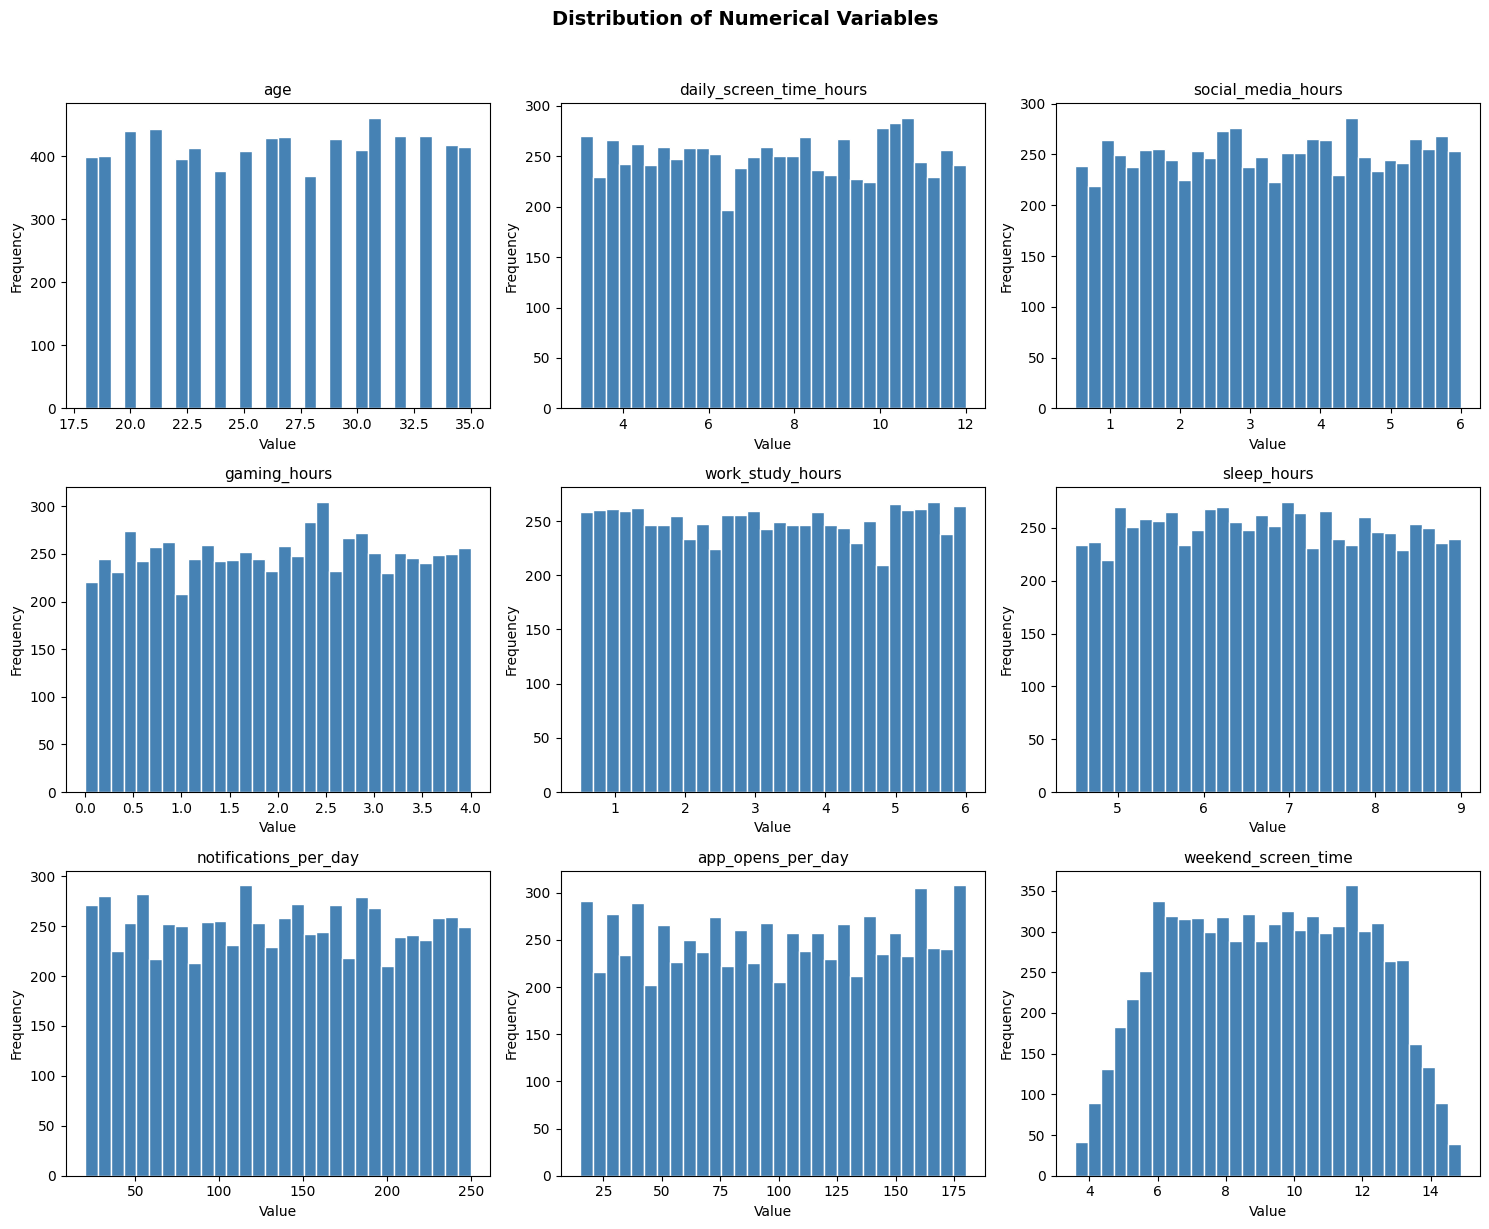

In [20]:
numerical_cols = [
    'age', 'daily_screen_time_hours', 'social_media_hours',
    'gaming_hours', 'work_study_hours', 'sleep_hours',
    'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df_clean[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Numerical Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Findings: Numerical Variables

Most numerical variables show a remarkably uniform distribution across their entire range,
which further supports the hypothesis that this dataset is synthetic. In real-world data,
variables such as `age`, `sleep_hours`, or `notifications_per_day` would typically follow
a normal or skewed distribution reflecting natural behavioral patterns.

The only exception is `weekend_screen_time`, which approximates a bell-shaped distribution
concentrated between 6 and 12 hours, making it the most organically distributed variable
in the dataset.

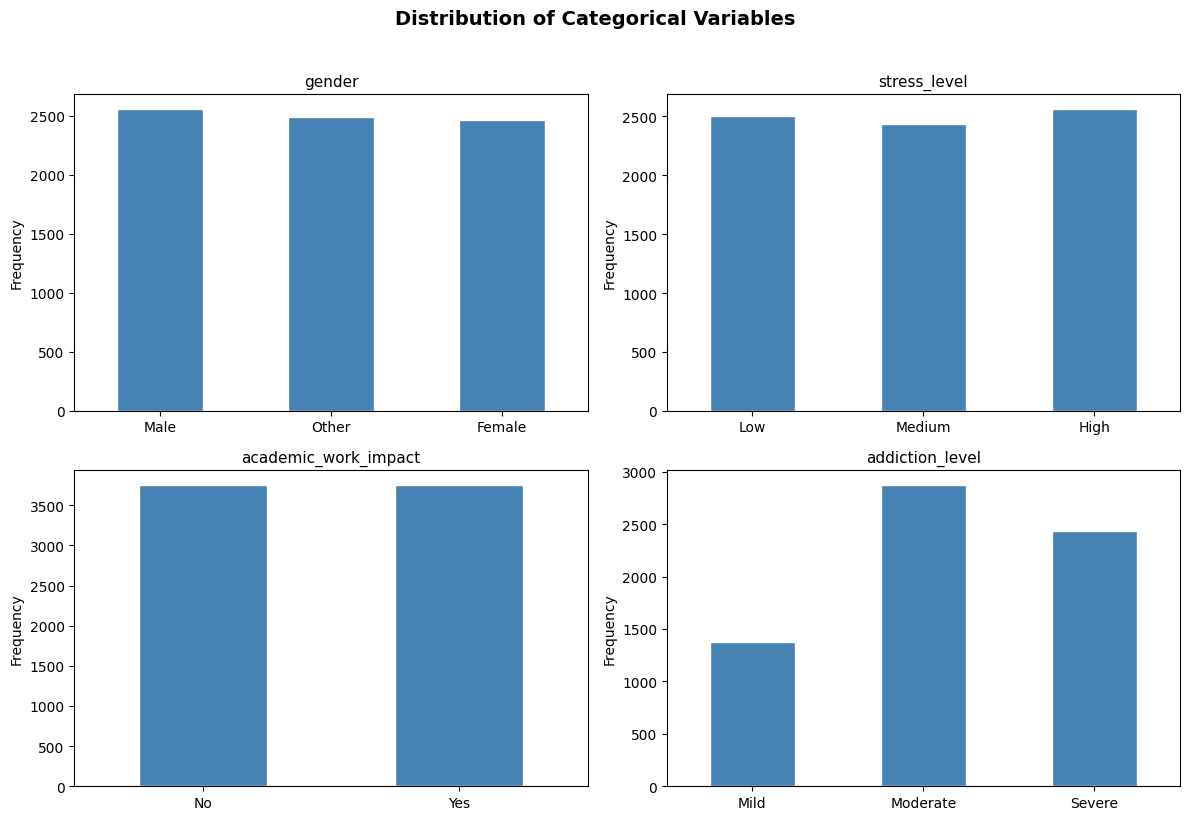

In [22]:
categorical_cols = ['gender', 'stress_level', 'academic_work_impact', 'addiction_level']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if hasattr(df_clean[col], 'cat') and df_clean[col].cat.ordered:
        order = df_clean[col].cat.categories.tolist()
    else:
        order = df_clean[col].value_counts().index.tolist()
    
    df_clean[col].value_counts().reindex(order).plot(
        kind='bar', ax=axes[i], color='steelblue', edgecolor='white'
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Distribution of Categorical Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Findings: Categorical Variables

All categorical variables confirm the synthetic nature of the dataset:

- `gender` and `stress_level` show near-perfect uniform distributions across all
  categories, which is highly unlikely in real-world behavioral data.

- `academic_work_impact` is almost perfectly split between `Yes` and `No` (50/50).

- `addiction_level` is the only categorical variable with a non-uniform distribution:
  `Moderate` is the most frequent category, followed by `Severe` and `Mild`.
  This suggests a deliberate skew toward higher addiction levels in the dataset design,
  which is consistent with the 71% addiction rate observed in `addicted_label`.
  Note that this chart reflects only the 6,681 non-null records (89.08% of the dataset).
  The remaining 10.92% missing values are excluded from this visualization.

## Bivariate Analysis
We examine the relationship between key variables and the target variable `addicted_label`
(0 = Not addicted, 1 = Addicted) to identify patterns and potential predictors of addiction.

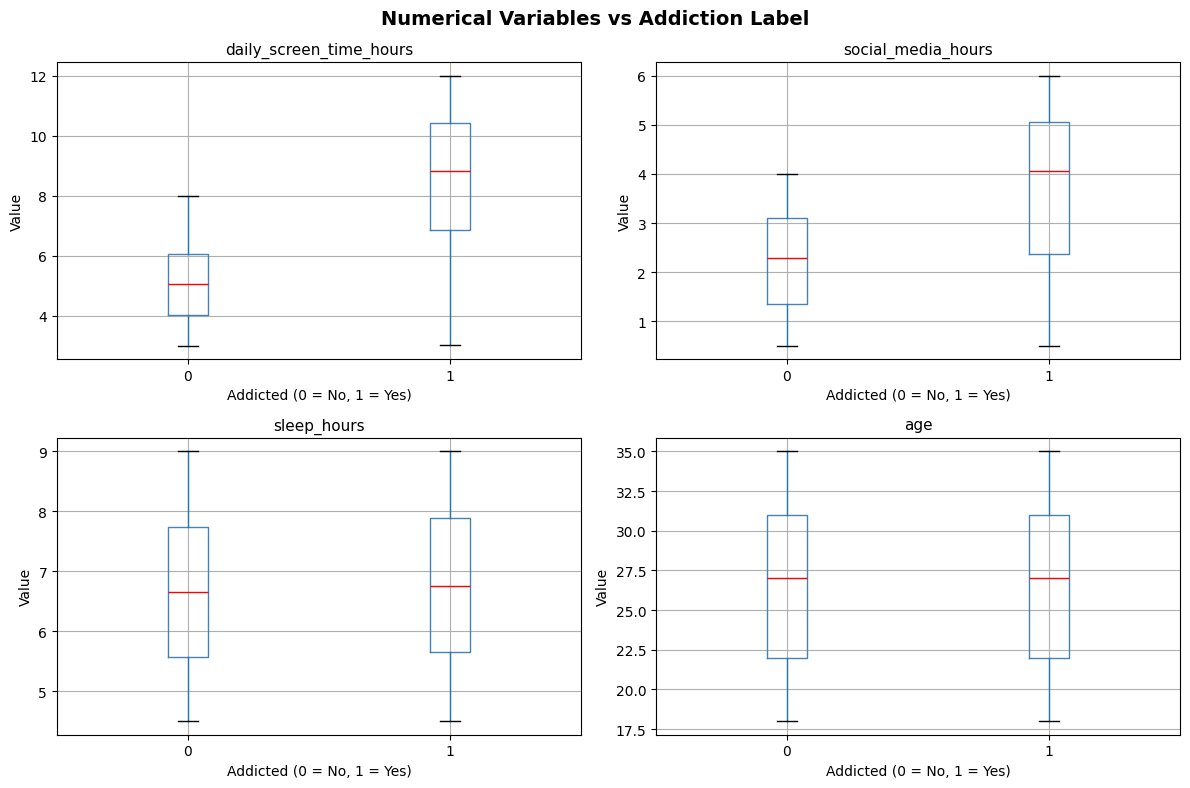

In [23]:
numerical_bivariate = [
    'daily_screen_time_hours', 'social_media_hours',
    'sleep_hours', 'age'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_bivariate):
    df_clean.boxplot(column=col, by='addicted_label', ax=axes[i], 
                     boxprops=dict(color='steelblue'),
                     medianprops=dict(color='red'))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Addicted (0 = No, 1 = Yes)')
    axes[i].set_ylabel('Value')

plt.suptitle('Numerical Variables vs Addiction Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/bt/yw47k8fj47jc6s7klvqq4qbw0000gn/T/ipykernel_60570/1035814022.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct = df_clean.groupby(col)['addicted_label'].mean() * 100
/var/folders/bt/yw47k8fj47jc6s7klvqq4qbw0000gn/T/ipykernel_60570/1035814022.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct = df_clean.groupby(col)['addicted_label'].mean() * 100


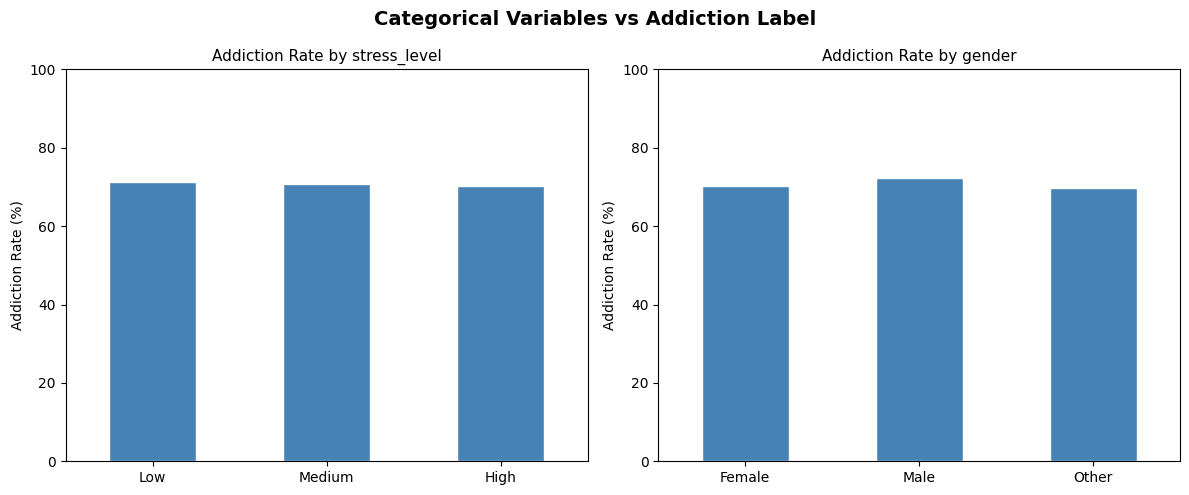

In [24]:
categorical_bivariate = ['stress_level', 'gender']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(categorical_bivariate):
    ct = df_clean.groupby(col)['addicted_label'].mean() * 100
    
    if hasattr(df_clean[col], 'cat') and df_clean[col].cat.ordered:
        ct = ct.reindex(df_clean[col].cat.categories.tolist())
    
    ct.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Addiction Rate by {col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Addiction Rate (%)')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].set_ylim(0, 100)

plt.suptitle('Categorical Variables vs Addiction Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Findings: Bivariate Analysis

**Strong predictors of addiction:**
- `daily_screen_time_hours` and `social_media_hours` show a clear separation between
  addicted and non-addicted users. Higher screen and social media time is consistently
  associated with addiction (addicted_label = 1).

**Weak or no predictors:**
- `sleep_hours` and `age` show virtually identical distributions across both groups,
  suggesting no meaningful relationship with addiction in this dataset.
- `stress_level` and `gender` show uniform addiction rates (~70%) across all categories,
  indicating no differential effect on addiction likelihood.

**Overall pattern:**
The only variables that differentiate addicted from non-addicted users are those directly
measuring screen usage behavior. Demographic variables (age, gender) and psychological
indicators (stress_level) show no discriminatory power, which is atypical of real-world
addiction data and further supports the synthetic nature of the dataset.

In [25]:
df[df['addiction_level'].isnull()][['age', 'gender', 'stress_level', 'daily_screen_time_hours']].describe()

,age,daily_screen_time_hours
count,819.000000,819.000000
mean,26.472527,4.522833
std,5.161468,0.860327
min,18.000000,3.000000
25%,22.000000,3.775000
50%,27.000000,4.520000
75%,31.000000,5.240000
max,35.000000,6.000000


## Correlation Analysis
We examine the linear relationships between all numerical variables using a correlation
heatmap. This helps identify which variables move together and potential multicollinearity
before any predictive modeling.

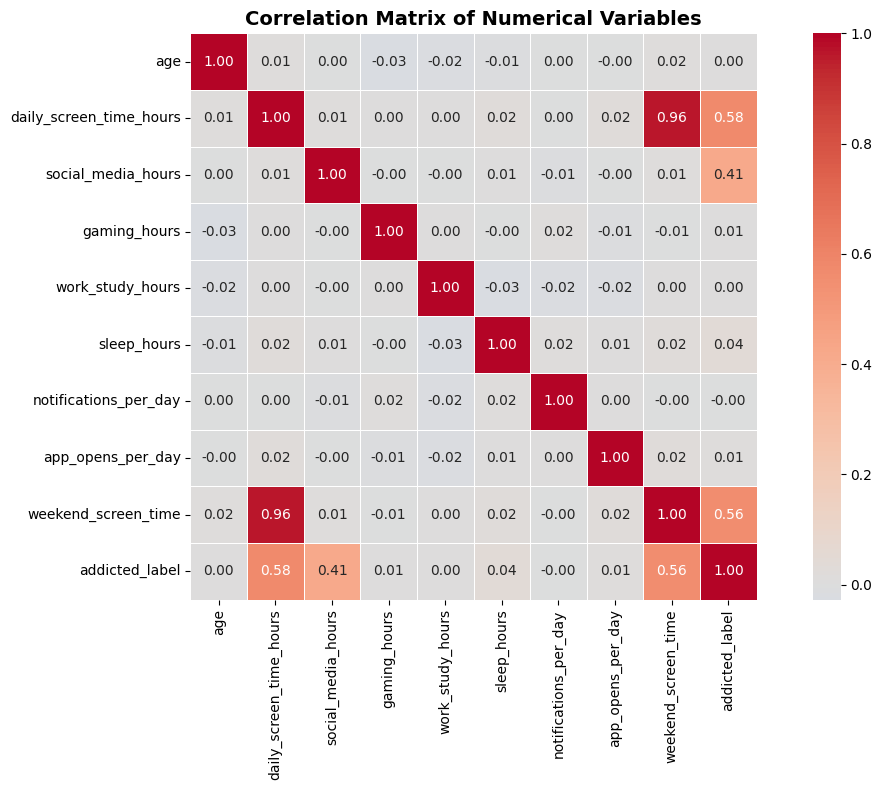

In [26]:
plt.figure(figsize=(12, 8))

correlation_matrix = df_clean.select_dtypes(include='number').corr()

sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Matrix of Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Findings: Correlation Analysis

**Strong positive correlations:**
- `daily_screen_time_hours` and `weekend_screen_time` show a near-perfect correlation
  (0.96), suggesting these two variables are almost redundant. In a predictive model,
  one of them should be considered for removal to avoid multicollinearity.
- `daily_screen_time_hours` (0.58) and `weekend_screen_time` (0.56) are the strongest
  numerical predictors of `addicted_label`, consistent with the bivariate analysis.
- `social_media_hours` shows a moderate correlation with `addicted_label` (0.41).

**No meaningful correlations:**
- `age`, `sleep_hours`, `gaming_hours`, `work_study_hours`, `notifications_per_day`,
  and `app_opens_per_day` show near-zero correlation with `addicted_label` and with
  each other, confirming their limited predictive value observed in the bivariate analysis.

**Overall pattern:**
Only screen time-related variables correlate with addiction. The absence of correlation
among most variables further reinforces the synthetic nature of the dataset.

## Outlier Detection
We use boxplots to visually identify outliers in the numerical variables. Outliers are
values that fall significantly outside the expected range and may distort statistical
analyses if not properly addressed.

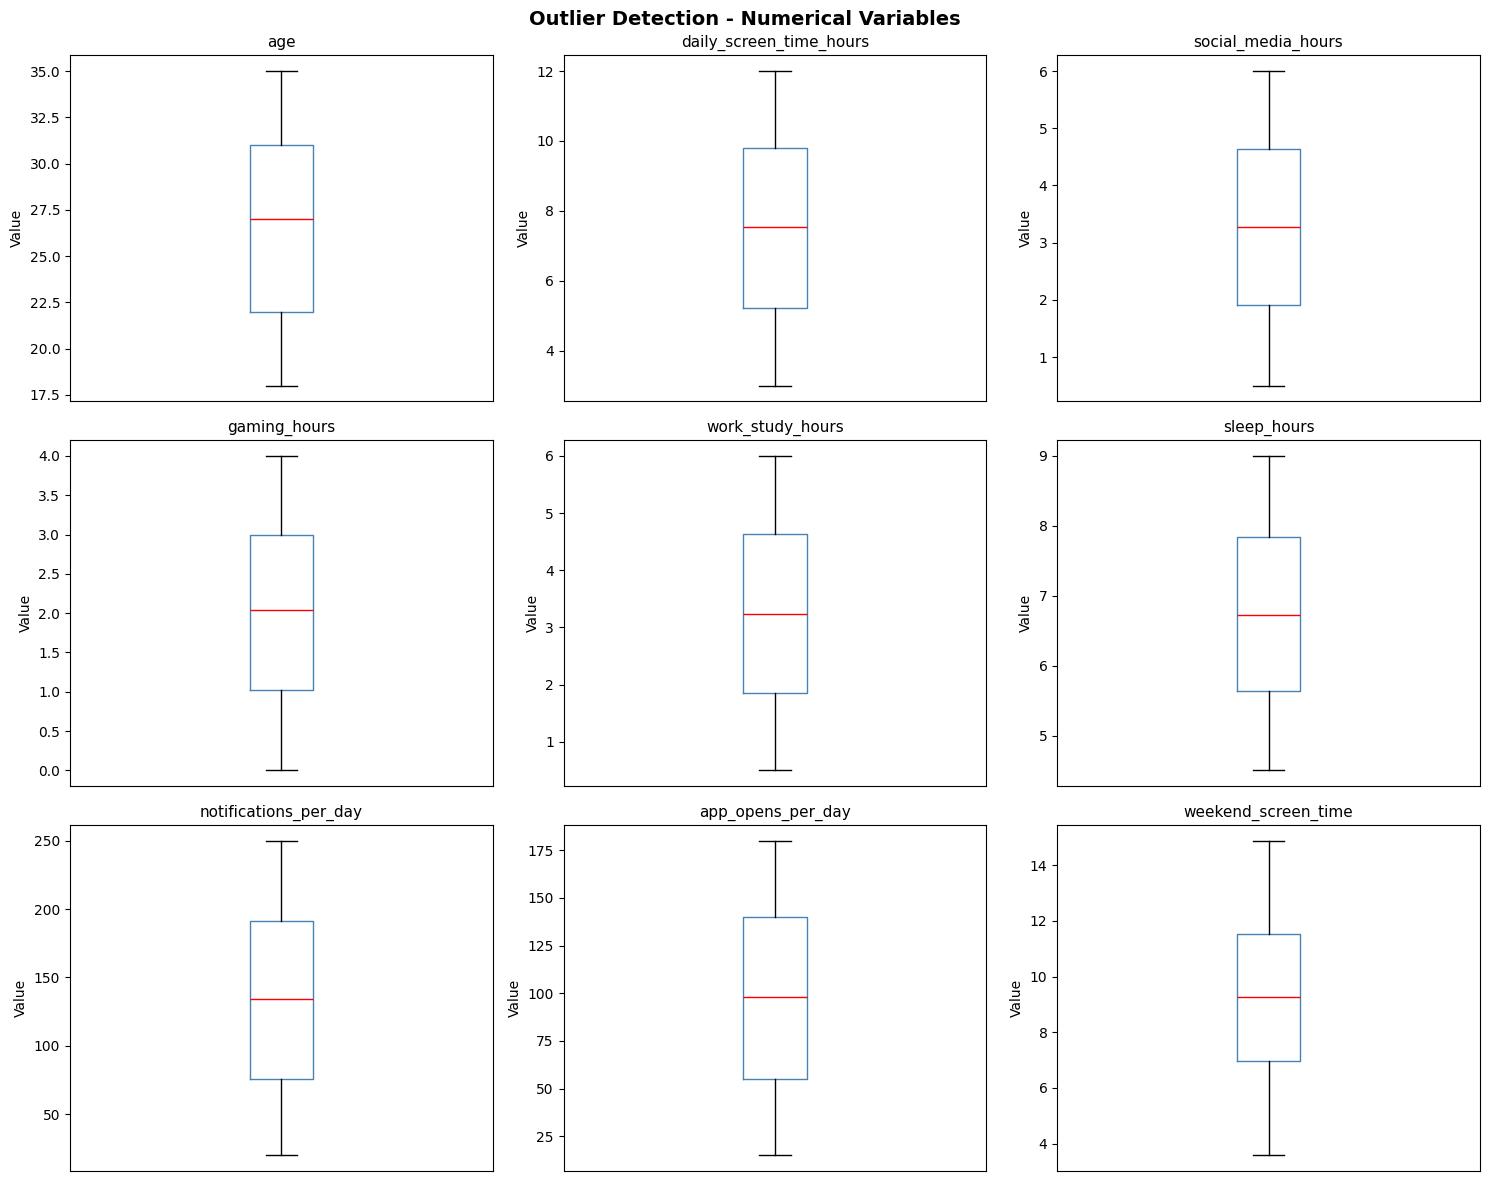

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df_clean[col].dropna(), 
                    boxprops=dict(color='steelblue'),
                    medianprops=dict(color='red'),
                    flierprops=dict(marker='o', color='steelblue', alpha=0.5))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

plt.suptitle('Outlier Detection - Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusions

This exploratory data analysis examined 7,500 records of smartphone usage behavior
with the goal of identifying patterns associated with addiction.

**On data quality:**
The dataset shows strong indicators of being synthetically generated. Numerical variables
display near-perfect uniform distributions, categorical variables are artificially balanced,
and no outliers were detected across any variable. These characteristics are highly unlikely
in real-world behavioral data and should be considered when generalizing findings.

**On missing values:**
Only `addiction_level` contained missing values (10.92%). Profile analysis revealed these
records tend to correspond to users with lower screen time (mean: 4.52h vs 7.50h),
suggesting MNAR (Missing Not At Random). The binary variable `addicted_label` was used
as a complete alternative throughout the analysis.

**On predictors of addiction:**
Screen time-related variables — `daily_screen_time_hours`, `weekend_screen_time`, and
`social_media_hours` — were the only meaningful predictors of addiction, showing moderate
to strong correlations (0.41–0.58) with `addicted_label`. Demographic variables (age,
gender) and behavioral indicators (sleep_hours, stress_level, notifications_per_day)
showed no discriminatory power.

**On multicollinearity:**
`daily_screen_time_hours` and `weekend_screen_time` are near-perfectly correlated (0.96),
making them redundant as joint predictors. Any subsequent modeling should retain only
one of these variables.